<font size="+3">TimeGAN — Per-Ticker OHLCV for DRL Pipeline</font>

# Imports & Settings

Per-ticker TimeGAN following Liu (2025) thesis approach:  
- Train one TimeGAN per ticker on its OHLCV (5 features)  
- Generate synthetic OHLCV per ticker  
- Compute tech indicators post-generation  
- Assemble into NPZ for ElegantRL CPCV pipeline

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os, sys, gc, time, shutil
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from pathlib import Path
from tqdm import tqdm
from dotenv import load_dotenv

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns

# Load Alpaca API keys from .env
load_dotenv(Path('..').resolve() / '.env')

# Add data/ to path so we can import processor_alpaca
sys.path.insert(0, str(Path('../..', 'datasets').resolve()))
from finrl.meta.data_processors.processor_alpaca import AlpacaProcessor


2026-03-04 17:13:11.777545: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 17:13:12.429745: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 17:13:14.672579: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print('Using GPU')
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print('Using CPU')

sns.set_style('white')

Using GPU


# Configuration

In [10]:
%matplotlib inline
# ── TimeGAN hyperparameters ──
seq_len    = 24
n_seq      = 5       # OHLCV features per ticker
batch_size = 128
hidden_dim = 24
num_layers = 3
train_steps = 10000
gamma      = 1

# ── Tickers & dates ──
TICKERS = [
    'AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS',
    'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM',
    'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT'
]

TRAIN_START = '2021-01-01'
TRAIN_END   = '2024-01-01'

feature_cols = ['open', 'high', 'low', 'close', 'volume']

# ── Paths ──
DATA_DIR    = Path('../..', 'datasets').resolve()
CACHE_CSV   = DATA_DIR / 'alpaca_ohlcv_28.csv'
results_path = Path('time_gan_drl_perticker')
results_path.mkdir(exist_ok=True)
hdf_store   = results_path / 'TimeSeriesGAN_perticker.h5'

# Download Data

In [6]:
def download_alpaca_data(force=False):
    """Download 28 DJIA tickers via AlpacaProcessor, cache to CSV."""
    if CACHE_CSV.exists() and not force:
        print(f'Loading cached data from {CACHE_CSV}')
        df = pd.read_csv(CACHE_CSV, parse_dates=['date'])
        print(f'  {len(df)} rows, {df.tic.nunique()} tickers, '
              f'{df.date.min().date()} -> {df.date.max().date()}')
        return df

    api_key = os.environ.get('ALPACA_API_KEY', '')
    api_secret = os.environ.get('ALPACA_API_SECRET', '')
    if not api_key or not api_secret:
        raise ValueError('Set ALPACA_API_KEY and ALPACA_API_SECRET in .env')

    dp = AlpacaProcessor(API_KEY=api_key, API_SECRET=api_secret)
    print(f'Downloading {len(TICKERS)} tickers from Alpaca...')
    raw = dp.download_data(ticker_list=TICKERS, start_date=TRAIN_START,
                           end_date=TRAIN_END, time_interval='1D')
    df = dp.clean_data(raw)

    try:
        df = dp.add_vix(df)
        if 'VIXY' in df.columns:
            df = df.rename(columns={'VIXY': 'vix'})
    except Exception as e:
        print(f'  VIX download failed ({e}), setting vix=0')
        df['vix'] = 0.0

    keep = ['date', 'tic', 'open', 'high', 'low', 'close', 'volume', 'vix']
    df = df[[c for c in keep if c in df.columns]]
    df = df.fillna(0).replace([np.inf, -np.inf], 0)
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['date', 'tic']).reset_index(drop=True)
    df.to_csv(CACHE_CSV, index=False)
    print(f'  Saved {len(df)} rows to {CACHE_CSV}')
    return df

In [7]:
raw_df = download_alpaca_data(force=False)
print(f'\nAvailable tickers: {sorted(raw_df.tic.unique())}')
print(f'Date range: {raw_df.date.min().date()} -> {raw_df.date.max().date()}')
print(f'Features: {[c for c in raw_df.columns if c not in ["date", "tic"]]}')

Loading cached data from /teamspace/studios/this_studio/ElegantRL/datasets/alpaca_ohlcv_28.csv
  21084 rows, 28 tickers, 2021-01-04 -> 2023-12-29

Available tickers: ['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT']
Date range: 2021-01-04 -> 2023-12-29
Features: ['open', 'high', 'low', 'close', 'volume', 'vix']


# Per-Ticker TimeGAN Functions

All TimeGAN logic consolidated into functions so we can loop over 28 tickers.  
Each ticker gets a fresh model trained on its own OHLCV data.

## 1. Data Preparation

In [5]:
def prepare_ticker_data(ticker, raw_df, feature_cols, seq_len, batch_size):
    """Extract one ticker's OHLCV, scale, create rolling windows & tf.data iterators."""
    df_tic = (raw_df[raw_df.tic == ticker]
              .sort_values('date')
              .set_index('date')[feature_cols]
              .dropna())
    n_seq = len(feature_cols)
    
    # MinMaxScale
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df_tic).astype(np.float32)
    
    # Rolling windows
    data = [scaled[i:i + seq_len] for i in range(len(df_tic) - seq_len)]
    n_windows = len(data)
    
    # tf.data.Dataset for real series
    real_ds = (tf.data.Dataset
               .from_tensor_slices(data)
               .shuffle(buffer_size=n_windows)
               .batch(batch_size))
    real_iter = iter(real_ds.repeat())
    
    # Random noise generator
    def make_random():
        while True:
            yield np.random.uniform(low=0, high=1, size=(seq_len, n_seq))
    
    rand_iter = iter(tf.data.Dataset
                     .from_generator(make_random, output_types=tf.float32)
                     .batch(batch_size)
                     .repeat())
    
    return {
        'df': df_tic,
        'scaler': scaler,
        'n_windows': n_windows,
        'n_seq': n_seq,
        'real_iter': real_iter,
        'rand_iter': rand_iter,
    }

## 2. Build TimeGAN

In [9]:
def build_timegan(seq_len, n_seq, hidden_dim, num_layers=3):
    """Build all TimeGAN components, return dict of models."""
    
    def make_rnn(n_layers, hidden_units, output_units, name):
        return Sequential(
            [GRU(units=hidden_units, return_sequences=True,
                 name=f'GRU_{i+1}') for i in range(n_layers)] +
            [Dense(units=output_units, activation='sigmoid', name='OUT')],
            name=name)
    
    # Components
    embedder      = make_rnn(num_layers, hidden_dim, hidden_dim, 'Embedder')
    recovery      = make_rnn(num_layers, hidden_dim, n_seq,      'Recovery')
    generator     = make_rnn(num_layers, hidden_dim, hidden_dim, 'Generator')
    discriminator = make_rnn(num_layers, hidden_dim, 1,          'Discriminator')
    supervisor    = make_rnn(2,          hidden_dim, hidden_dim, 'Supervisor')
    
    # Input placeholders
    X = Input(shape=[seq_len, n_seq], name='RealData')
    Z = Input(shape=[seq_len, n_seq], name='RandomData')
    
    # Autoencoder
    H = embedder(X)
    X_tilde = recovery(H)
    autoencoder = Model(inputs=X, outputs=X_tilde, name='Autoencoder')
    
    # Adversarial supervised
    E_hat = generator(Z)
    H_hat = supervisor(E_hat)
    Y_fake = discriminator(H_hat)
    adversarial_supervised = Model(inputs=Z, outputs=Y_fake,
                                   name='AdversarialNetSupervised')
    
    # Adversarial in latent space
    Y_fake_e = discriminator(E_hat)
    adversarial_emb = Model(inputs=Z, outputs=Y_fake_e,
                            name='AdversarialNet')
    
    # Synthetic data model
    X_hat = recovery(H_hat)
    synthetic_data = Model(inputs=Z, outputs=X_hat, name='SyntheticData')
    
    # Discriminator on real data
    Y_real = discriminator(H)
    discriminator_model = Model(inputs=X, outputs=Y_real,
                                name='DiscriminatorReal')
    
    return {
        'embedder': embedder,
        'recovery': recovery,
        'generator': generator,
        'discriminator': discriminator,
        'supervisor': supervisor,
        'autoencoder': autoencoder,
        'adversarial_supervised': adversarial_supervised,
        'adversarial_emb': adversarial_emb,
        'synthetic_data': synthetic_data,
        'discriminator_model': discriminator_model,
    }

## 3. Train TimeGAN

In [10]:
def train_timegan(models, real_iter, rand_iter, train_steps, gamma=1,
                  writer=None, verbose=True, checkpoint_dir=None, ckpt_interval=2000):
    """Run all 3 training phases with tf.train.Checkpoint for crash recovery.
    
    Uses tf.train.Checkpoint + CheckpointManager for:
      - Atomic writes (no corrupt checkpoints on crash)
      - Optimizer state preservation (Adam momentum/velocity survive resume)
      - Auto-pruning of old checkpoints (max_to_keep=2)
      - Built-in discovery via tf.train.latest_checkpoint()
    
    Checkpointing strategy:
      - After Phase 1 & 2 complete: save all weights + optimizer state + phase counter
      - During Phase 3: save every `ckpt_interval` steps (default 2000)
      - On resume: skip completed phases, resume Phase 3 from last checkpoint
    """
    
    embedder              = models['embedder']
    recovery              = models['recovery']
    generator             = models['generator']
    supervisor            = models['supervisor']
    autoencoder           = models['autoencoder']
    adversarial_supervised = models['adversarial_supervised']
    adversarial_emb       = models['adversarial_emb']
    synthetic_data        = models['synthetic_data']
    discriminator_model   = models['discriminator_model']
    
    mse = MeanSquaredError()
    bce = BinaryCrossentropy()
    
    # ── Create ALL optimizers upfront so checkpoint can track them ──
    ae_opt   = Adam()
    sup_opt  = Adam()
    gen_opt  = Adam()
    disc_opt = Adam()
    emb_opt  = Adam()
    
    # ── Trackable phase/step counters ──
    phase_var = tf.Variable(0, dtype=tf.int64, name='phase')
    step_var  = tf.Variable(0, dtype=tf.int64, name='step')
    
    # ── Single checkpoint: all 5 components + 5 optimizers + 2 counters ──
    ckpt = tf.train.Checkpoint(
        embedder=embedder,
        recovery=recovery,
        generator=generator,
        supervisor=supervisor,
        discriminator=models['discriminator'],
        ae_optimizer=ae_opt,
        sup_optimizer=sup_opt,
        gen_optimizer=gen_opt,
        disc_optimizer=disc_opt,
        emb_optimizer=emb_opt,
        phase=phase_var,
        step=step_var,
    )
    
    manager = None
    resume_phase = 0
    resume_step = 0
    
    if checkpoint_dir is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)
        manager = tf.train.CheckpointManager(ckpt, str(checkpoint_dir), max_to_keep=2)
        
        if manager.latest_checkpoint:
            ckpt.restore(manager.latest_checkpoint).expect_partial()
            resume_phase = int(phase_var.numpy())
            resume_step  = int(step_var.numpy())
            if verbose:
                print(f'  >> Restored from {manager.latest_checkpoint} '
                      f'(phase={resume_phase}, step={resume_step})')
    
    def save_ckpt(phase, step):
        """Atomically save checkpoint with phase/step metadata."""
        if manager is None:
            return
        phase_var.assign(phase)
        step_var.assign(step)
        path = manager.save()
        if verbose:
            print(f'    [checkpoint saved] {Path(path).name} — phase={phase}, step={step}')
    
    # ── Phase 1: Autoencoder ──
    if resume_phase < 1:
        @tf.function
        def train_autoencoder_init(x):
            with tf.GradientTape() as tape:
                x_tilde = autoencoder(x)
                embedding_loss_t0 = mse(x, x_tilde)
                e_loss_0 = 10 * tf.sqrt(embedding_loss_t0)
            var_list = embedder.trainable_variables + recovery.trainable_variables
            gradients = tape.gradient(e_loss_0, var_list)
            ae_opt.apply_gradients(zip(gradients, var_list))
            return tf.sqrt(embedding_loss_t0)
        
        if verbose: print('  Phase 1: Autoencoder')
        for step in tqdm(range(train_steps), disable=not verbose, desc='    AE'):
            X_ = next(real_iter)
            step_e_loss_t0 = train_autoencoder_init(X_)
            if writer is not None:
                with writer.as_default():
                    tf.summary.scalar('Loss Autoencoder Init', step_e_loss_t0, step=step)
        if verbose: print(f'    Final AE loss: {step_e_loss_t0:.4f}')
        save_ckpt(phase=1, step=0)
    else:
        if verbose: print('  Phase 1: Autoencoder — skipped (checkpoint)')
    
    # ── Phase 2: Supervisor ──
    if resume_phase < 2:
        @tf.function
        def train_supervisor(x):
            with tf.GradientTape() as tape:
                h = embedder(x)
                h_hat = supervisor(h)
                g_loss_s = mse(h[:, 1:, :], h_hat[:, :-1, :])
            gradients = tape.gradient(g_loss_s, supervisor.trainable_variables)
            sup_opt.apply_gradients(zip(gradients, supervisor.trainable_variables))
            return g_loss_s
        
        if verbose: print('  Phase 2: Supervisor')
        for step in tqdm(range(train_steps), disable=not verbose, desc='    Sup'):
            X_ = next(real_iter)
            step_g_loss_s = train_supervisor(X_)
            if writer is not None:
                with writer.as_default():
                    tf.summary.scalar('Loss Generator Supervised Init', step_g_loss_s, step=step)
        if verbose: print(f'    Final Sup loss: {step_g_loss_s:.4f}')
        save_ckpt(phase=2, step=0)
    else:
        if verbose: print('  Phase 2: Supervisor — skipped (checkpoint)')
    
    # ── Phase 3: Joint Training ──
    start_step = resume_step if resume_phase == 3 else 0
    
    if start_step >= train_steps:
        if verbose: print('  Phase 3: Joint training — skipped (checkpoint)')
        return models
    
    @tf.function
    def train_generator(x, z):
        with tf.GradientTape() as tape:
            y_fake = adversarial_supervised(z)
            g_loss_u = bce(y_true=tf.ones_like(y_fake), y_pred=y_fake)
            y_fake_e = adversarial_emb(z)
            g_loss_u_e = bce(y_true=tf.ones_like(y_fake_e), y_pred=y_fake_e)
            h = embedder(x)
            h_hat = supervisor(h)
            g_loss_s = mse(h[:, 1:, :], h_hat[:, 1:, :])
            x_hat = synthetic_data(z)
            g_loss_v = get_moment_loss(x, x_hat)
            g_loss = (g_loss_u + g_loss_u_e +
                      100 * tf.sqrt(g_loss_s) + 100 * g_loss_v)
        var_list = generator.trainable_variables + supervisor.trainable_variables
        gradients = tape.gradient(g_loss, var_list)
        gen_opt.apply_gradients(zip(gradients, var_list))
        return g_loss_u, g_loss_s, g_loss_v
    
    @tf.function
    def train_embedder(x):
        with tf.GradientTape() as tape:
            h = embedder(x)
            h_hat = supervisor(h)
            g_loss_s = mse(h[:, 1:, :], h_hat[:, 1:, :])
            x_tilde = autoencoder(x)
            e_loss_t0 = mse(x, x_tilde)
            e_loss = 10 * tf.sqrt(e_loss_t0) + 0.1 * g_loss_s
        var_list = embedder.trainable_variables + recovery.trainable_variables
        gradients = tape.gradient(e_loss, var_list)
        emb_opt.apply_gradients(zip(gradients, var_list))
        return tf.sqrt(e_loss_t0)
    
    @tf.function
    def get_discriminator_loss(x, z):
        y_real = discriminator_model(x)
        d_loss_real = bce(y_true=tf.ones_like(y_real), y_pred=y_real)
        y_fake = adversarial_supervised(z)
        d_loss_fake = bce(y_true=tf.zeros_like(y_fake), y_pred=y_fake)
        y_fake_e = adversarial_emb(z)
        d_loss_fake_e = bce(y_true=tf.zeros_like(y_fake_e), y_pred=y_fake_e)
        return d_loss_real + d_loss_fake + gamma * d_loss_fake_e
    
    @tf.function
    def train_discriminator(x, z):
        with tf.GradientTape() as tape:
            d_loss = get_discriminator_loss(x, z)
        var_list = models['discriminator'].trainable_variables
        gradients = tape.gradient(d_loss, var_list)
        disc_opt.apply_gradients(zip(gradients, var_list))
        return d_loss
    
    def get_moment_loss(y_true, y_pred):
        y_true_mean, y_true_var = tf.nn.moments(x=y_true, axes=[0])
        y_pred_mean, y_pred_var = tf.nn.moments(x=y_pred, axes=[0])
        g_loss_mean = tf.reduce_mean(tf.abs(y_true_mean - y_pred_mean))
        g_loss_var = tf.reduce_mean(
            tf.abs(tf.sqrt(y_true_var + 1e-6) - tf.sqrt(y_pred_var + 1e-6)))
        return g_loss_mean + g_loss_var
    
    step_g_loss_u = step_g_loss_s = step_g_loss_v = step_e_loss_t0 = step_d_loss = 0
    if verbose:
        label = '  Phase 3: Joint training'
        if start_step > 0:
            label += f' (resuming from step {start_step})'
        print(label)
    for step in tqdm(range(start_step, train_steps), disable=not verbose,
                     desc='    Joint', initial=start_step, total=train_steps):
        for _ in range(2):
            X_ = next(real_iter)
            Z_ = next(rand_iter)
            step_g_loss_u, step_g_loss_s, step_g_loss_v = train_generator(X_, Z_)
            step_e_loss_t0 = train_embedder(X_)
        
        X_ = next(real_iter)
        Z_ = next(rand_iter)
        step_d_loss = get_discriminator_loss(X_, Z_)
        if step_d_loss > 0.15:
            step_d_loss = train_discriminator(X_, Z_)
        
        if verbose and step % 1000 == 0:
            print(f'{step:6,d} | d_loss: {step_d_loss:6.4f} | g_loss_u: {step_g_loss_u:6.4f} | '
                  f'g_loss_s: {step_g_loss_s:6.4f} | g_loss_v: {step_g_loss_v:6.4f} | e_loss_t0: {step_e_loss_t0:6.4f}')
        
        if writer is not None:
            with writer.as_default():
                tf.summary.scalar('G Loss S', step_g_loss_s, step=step)
                tf.summary.scalar('G Loss U', step_g_loss_u, step=step)
                tf.summary.scalar('G Loss V', step_g_loss_v, step=step)
                tf.summary.scalar('E Loss T0', step_e_loss_t0, step=step)
                tf.summary.scalar('D Loss', step_d_loss, step=step)
        
        # Periodic checkpoint during Phase 3
        if step > 0 and step % ckpt_interval == 0:
            save_ckpt(phase=3, step=step)
    
    return models

## 4. Generate & Store Synthetic Data

In [11]:
def generate_synthetic(ticker, models, data_info, seq_len, batch_size, hdf_store):
    """Generate synthetic OHLCV, inverse-transform, persist to HDF5."""
    synthetic_model = models['synthetic_data']
    scaler    = data_info['scaler']
    n_windows = data_info['n_windows']
    n_seq     = data_info['n_seq']
    rand_iter = data_info['rand_iter']
    
    # Generate
    generated = []
    for _ in range(max(1, n_windows // batch_size)):
        Z_ = next(rand_iter)
        generated.append(synthetic_model(Z_).numpy())
    generated = np.vstack(generated)
    
    # Inverse transform back to original scale
    generated = (scaler.inverse_transform(generated.reshape(-1, n_seq))
                 .reshape(-1, seq_len, n_seq))
    
    # Store in HDF5
    flat = generated.reshape(-1, n_seq)
    syn_df = pd.DataFrame(flat, columns=feature_cols)
    with pd.HDFStore(hdf_store) as store:
        store.put(f'{ticker}/synthetic', syn_df)
    
    print(f'    Generated {generated.shape[0]} windows '
          f'({flat.shape[0]} rows) -> {ticker}/synthetic')
    return generated

# Main Loop — Train TimeGAN per Ticker

For each of the 28 DJIA tickers:  
1. Extract & scale its OHLCV  
2. Build a fresh TimeGAN  
3. Train all 3 phases (10k steps each)  
4. Generate synthetic OHLCV & store  
5. Clear TF session to free GPU memory

In [12]:
# Track which tickers are already done (for resume capability)
completed = set()
if hdf_store.exists():
    with pd.HDFStore(hdf_store, mode='r') as store:
        for key in store.keys():
            # keys look like '/AAPL/synthetic'
            parts = key.strip('/').split('/')
            if len(parts) == 2 and parts[1] == 'synthetic':
                completed.add(parts[0])
    if completed:
        print(f'Already completed: {sorted(completed)}')

remaining = [t for t in TICKERS if t not in completed]
print(f'{len(remaining)} tickers remaining: {remaining}')

Already completed: ['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON']
16 tickers remaining: ['IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT']


In [13]:
all_generated = {}   # ticker -> generated_data array

for i, ticker in enumerate(remaining):
    t0 = time.time()
    print(f'\n{"="*60}')
    print(f'  [{i+1}/{len(remaining)}] {ticker}')
    print(f'{"="*60}')
    
    # 1. Prepare data
    data_info = prepare_ticker_data(ticker, raw_df, feature_cols, seq_len, batch_size)
    print(f'  {len(data_info["df"])} trading days, {data_info["n_windows"]} windows')
    
    # 2. TensorBoard writer per ticker
    log_dir = results_path / ticker
    log_dir.mkdir(parents=True, exist_ok=True)
    writer = tf.summary.create_file_writer(log_dir.as_posix())
    
    # 3. Checkpoint directory (inside ticker log dir)
    ckpt_dir = log_dir / 'checkpoints'
    
    # 4. Build fresh model
    models = build_timegan(seq_len, n_seq, hidden_dim, num_layers)
    
    # 5. Train all 3 phases (auto-resumes from checkpoint if one exists)
    models = train_timegan(models, data_info['real_iter'], data_info['rand_iter'],
                           train_steps, gamma, writer=writer,
                           checkpoint_dir=ckpt_dir)
    
    # 6. Generate & store
    gen_data = generate_synthetic(ticker, models, data_info, seq_len, batch_size, hdf_store)
    all_generated[ticker] = gen_data
    
    # 7. Save model & generated data (like single_tic)
    models['synthetic_data'].save(log_dir / 'synthetic_data.keras')
    np.save(log_dir / 'generated_data.npy', gen_data)
    
    # 8. Also store the real data for later comparison
    with pd.HDFStore(hdf_store) as store:
        store.put(f'{ticker}/real', data_info['df'])
    
    # 9. Clean up checkpoint files (training completed successfully)
    if ckpt_dir.exists():
        shutil.rmtree(ckpt_dir)
        print(f'  Checkpoint files cleaned up')
    
    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min')
    
    # 10. Clear session to free GPU memory
    del models, data_info, gen_data, writer
    tf.keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print(f'All {len(TICKERS)} tickers complete!')
print(f'{"="*60}')


  [1/16] IBM


I0000 00:00:1772550939.217889 2748858 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20735 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:04.0, compute capability: 8.9


  753 trading days, 729 windows
  >> Restored from time_gan_drl_perticker/IBM/checkpoints/ckpt-4 (phase=3, step=4000)
  Phase 1: Autoencoder — skipped (checkpoint)
  Phase 2: Supervisor — skipped (checkpoint)
  Phase 3: Joint training (resuming from step 4000)


    Joint:  40%|████      | 4000/10000 [00:00<?, ?it/s]2026-03-03 15:15:50.987510: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


 4,000 | d_loss: 1.7880 | g_loss_u: 1.3322 | g_loss_s: 0.0001 | g_loss_v: 0.0282 | e_loss_t0: 0.0050


...

    [checkpoint saved] ckpt-6 — phase=3, step=8000


    Joint:  90%|█████████ | 9001/10000 [47:46<05:16,  3.15it/s]

 9,000 | d_loss: 1.5023 | g_loss_u: 1.9196 | g_loss_s: 0.0001 | g_loss_v: 0.0344 | e_loss_t0: 0.0039


    Joint: 100%|██████████| 10000/10000 [53:00<00:00,  3.14it/s]


    Generated 640 windows (15360 rows) -> WMT/synthetic
  Checkpoint files cleaned up
  Done in 56.8 min

All 28 tickers complete!


# Inspect Results

In [6]:
# List all keys in the HDF5 store
with pd.HDFStore(hdf_store, mode='r') as store:
    print('HDF5 keys:')
    for key in sorted(store.keys()):
        df_tmp = store[key]
        print(f'  {key}: {df_tmp.shape}')

HDF5 keys:
  /AAPL/real: (753, 5)
  /AAPL/synthetic: (15360, 5)
  /AMGN/real: (753, 5)
  /AMGN/synthetic: (15360, 5)
  /AXP/real: (753, 5)
  /AXP/synthetic: (15360, 5)
  /BA/real: (753, 5)
  /BA/synthetic: (15360, 5)
  /CAT/real: (753, 5)
  /CAT/synthetic: (15360, 5)
  /CRM/real: (753, 5)
  /CRM/synthetic: (15360, 5)
  /CSCO/real: (753, 5)
  /CSCO/synthetic: (15360, 5)
  /CVX/real: (753, 5)
  /CVX/synthetic: (15360, 5)
  /DIS/real: (753, 5)
  /DIS/synthetic: (15360, 5)
  /GS/real: (753, 5)
  /GS/synthetic: (15360, 5)
  /HD/real: (753, 5)
  /HD/synthetic: (15360, 5)
  /HON/real: (753, 5)
  /HON/synthetic: (15360, 5)
  /IBM/real: (753, 5)
  /IBM/synthetic: (15360, 5)
  /INTC/real: (753, 5)
  /INTC/synthetic: (15360, 5)
  /JNJ/real: (753, 5)
  /JNJ/synthetic: (15360, 5)
  /JPM/real: (753, 5)
  /JPM/synthetic: (15360, 5)
  /KO/real: (753, 5)
  /KO/synthetic: (15360, 5)
  /MCD/real: (753, 5)
  /MCD/synthetic: (15360, 5)
  /MMM/real: (753, 5)
  /MMM/synthetic: (15360, 5)
  /MRK/real: (753, 5

## Plot Real vs Synthetic (sample tickers)

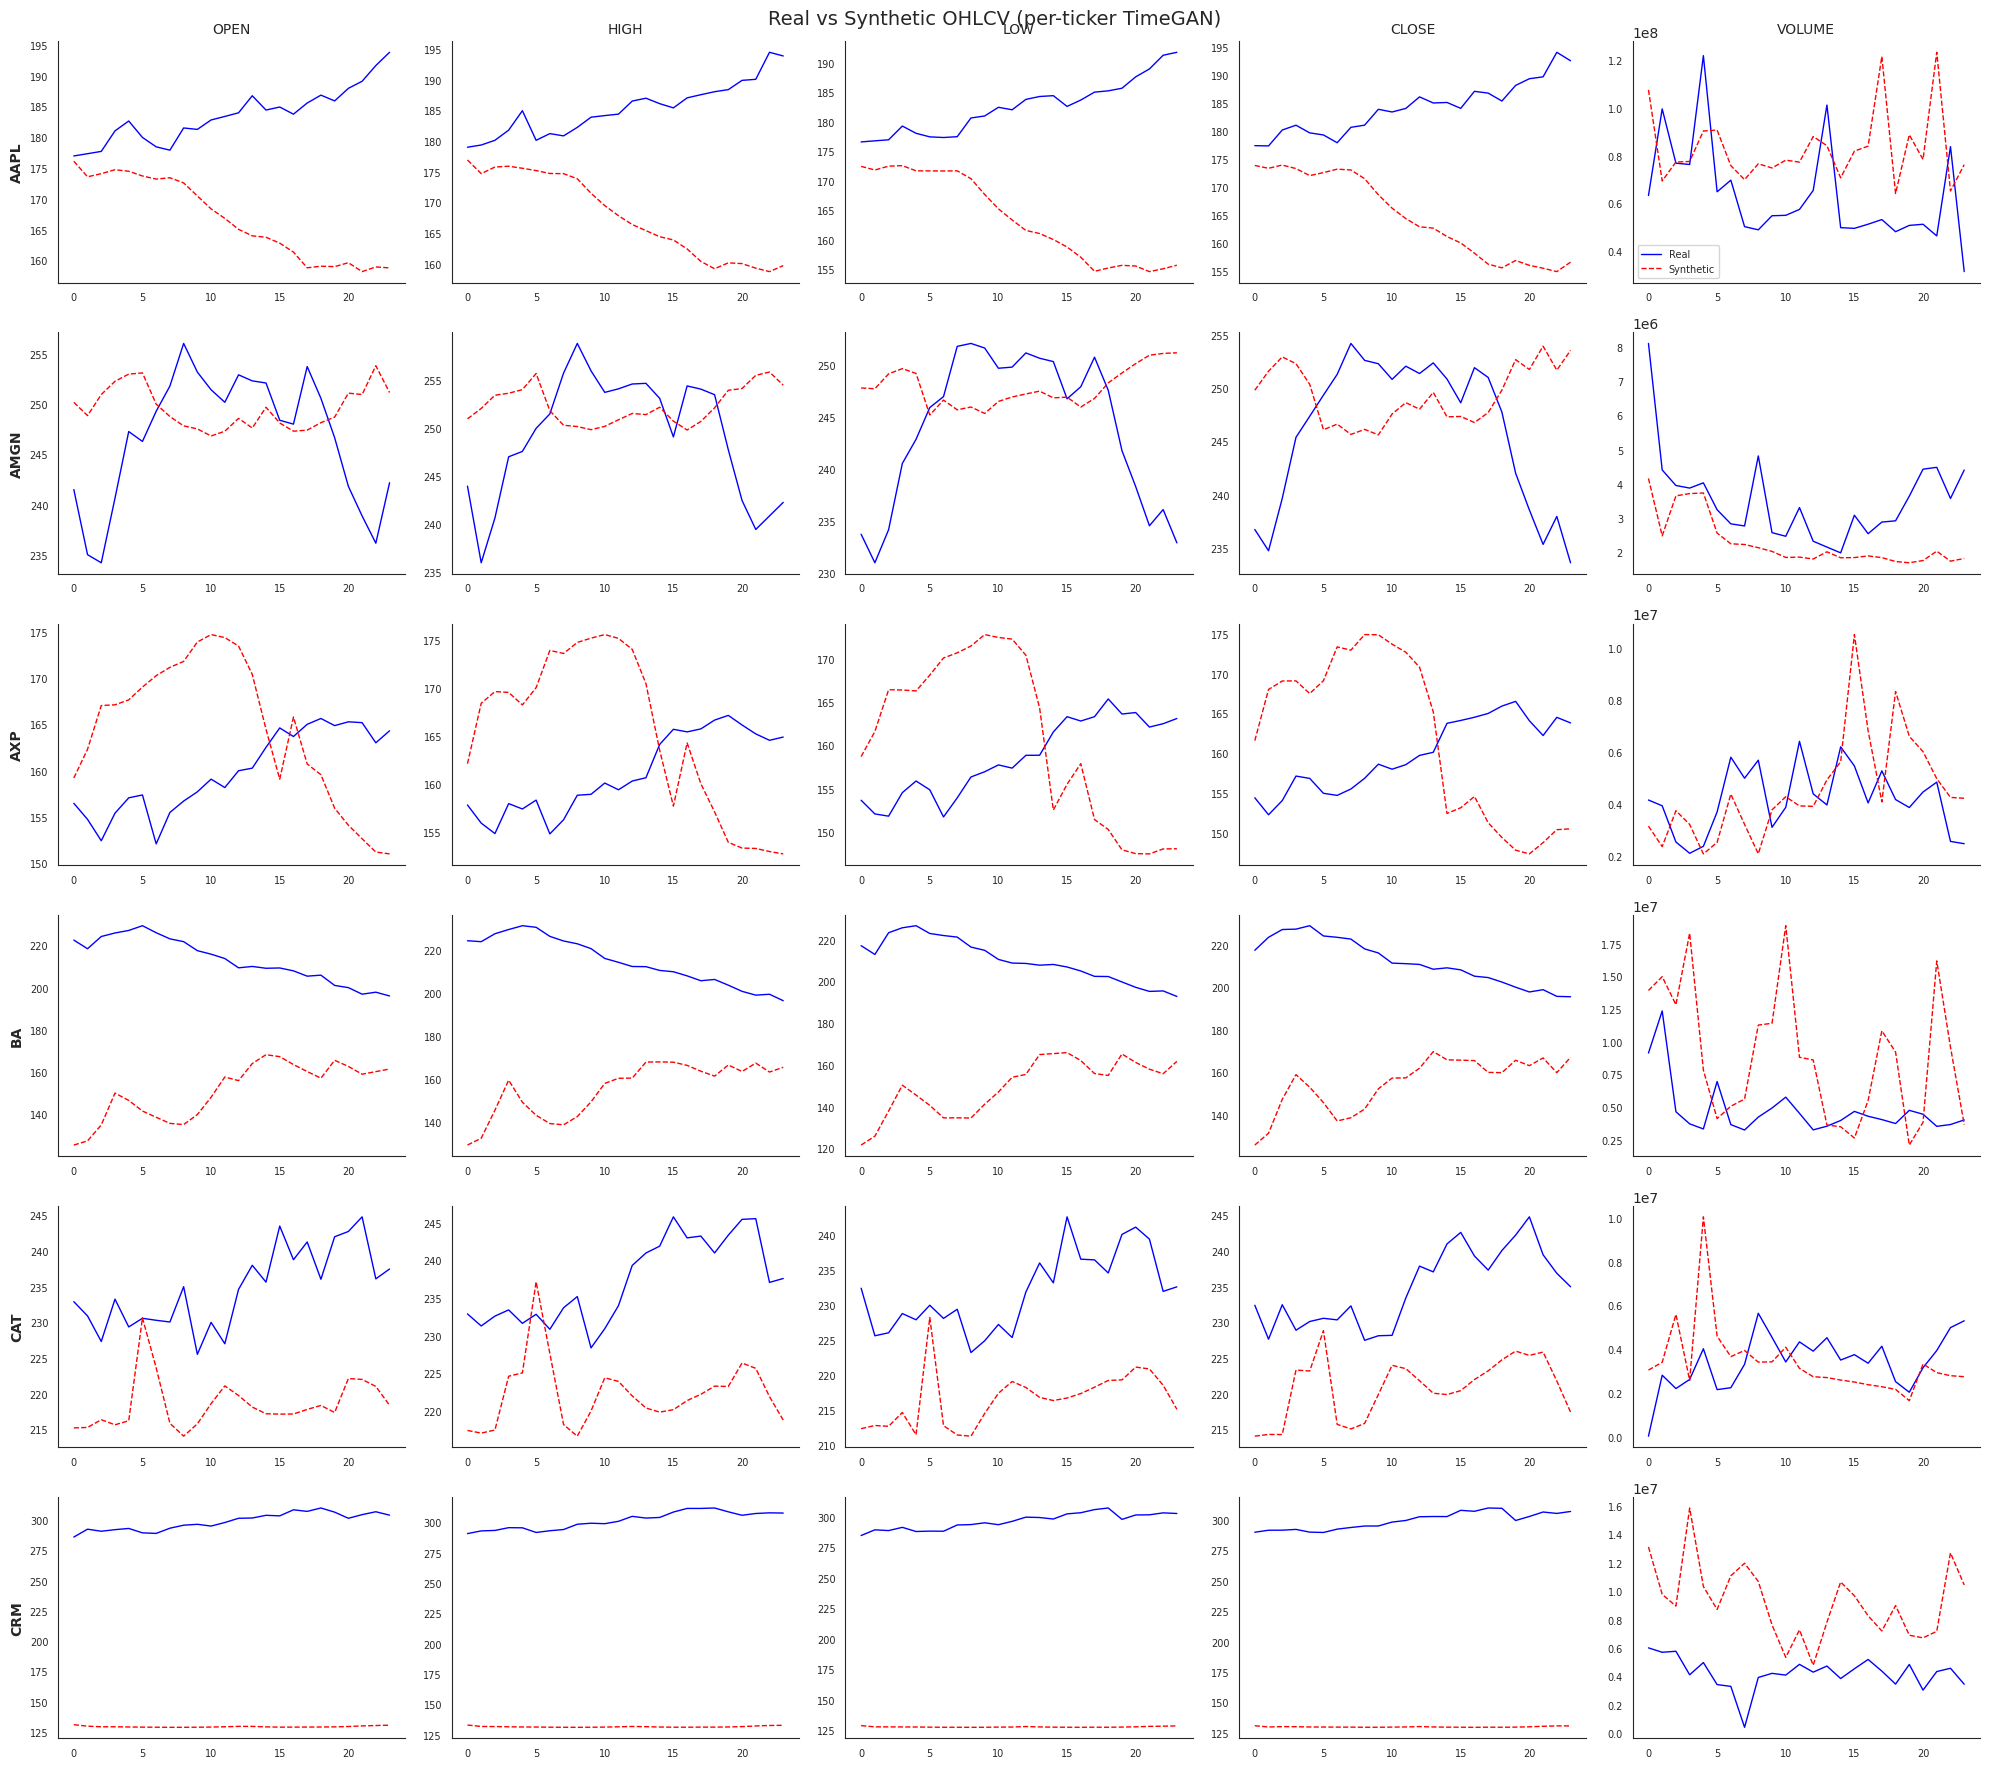

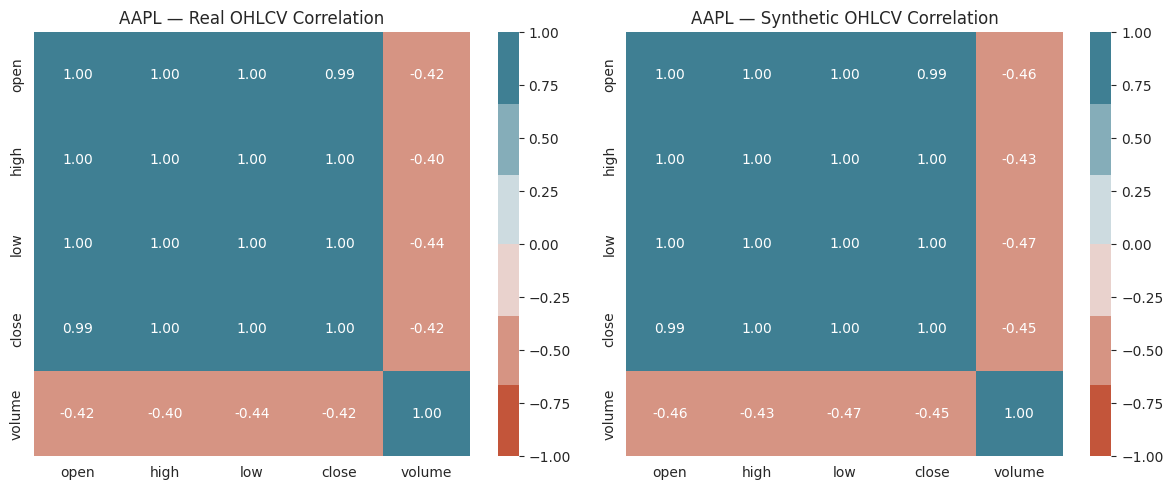

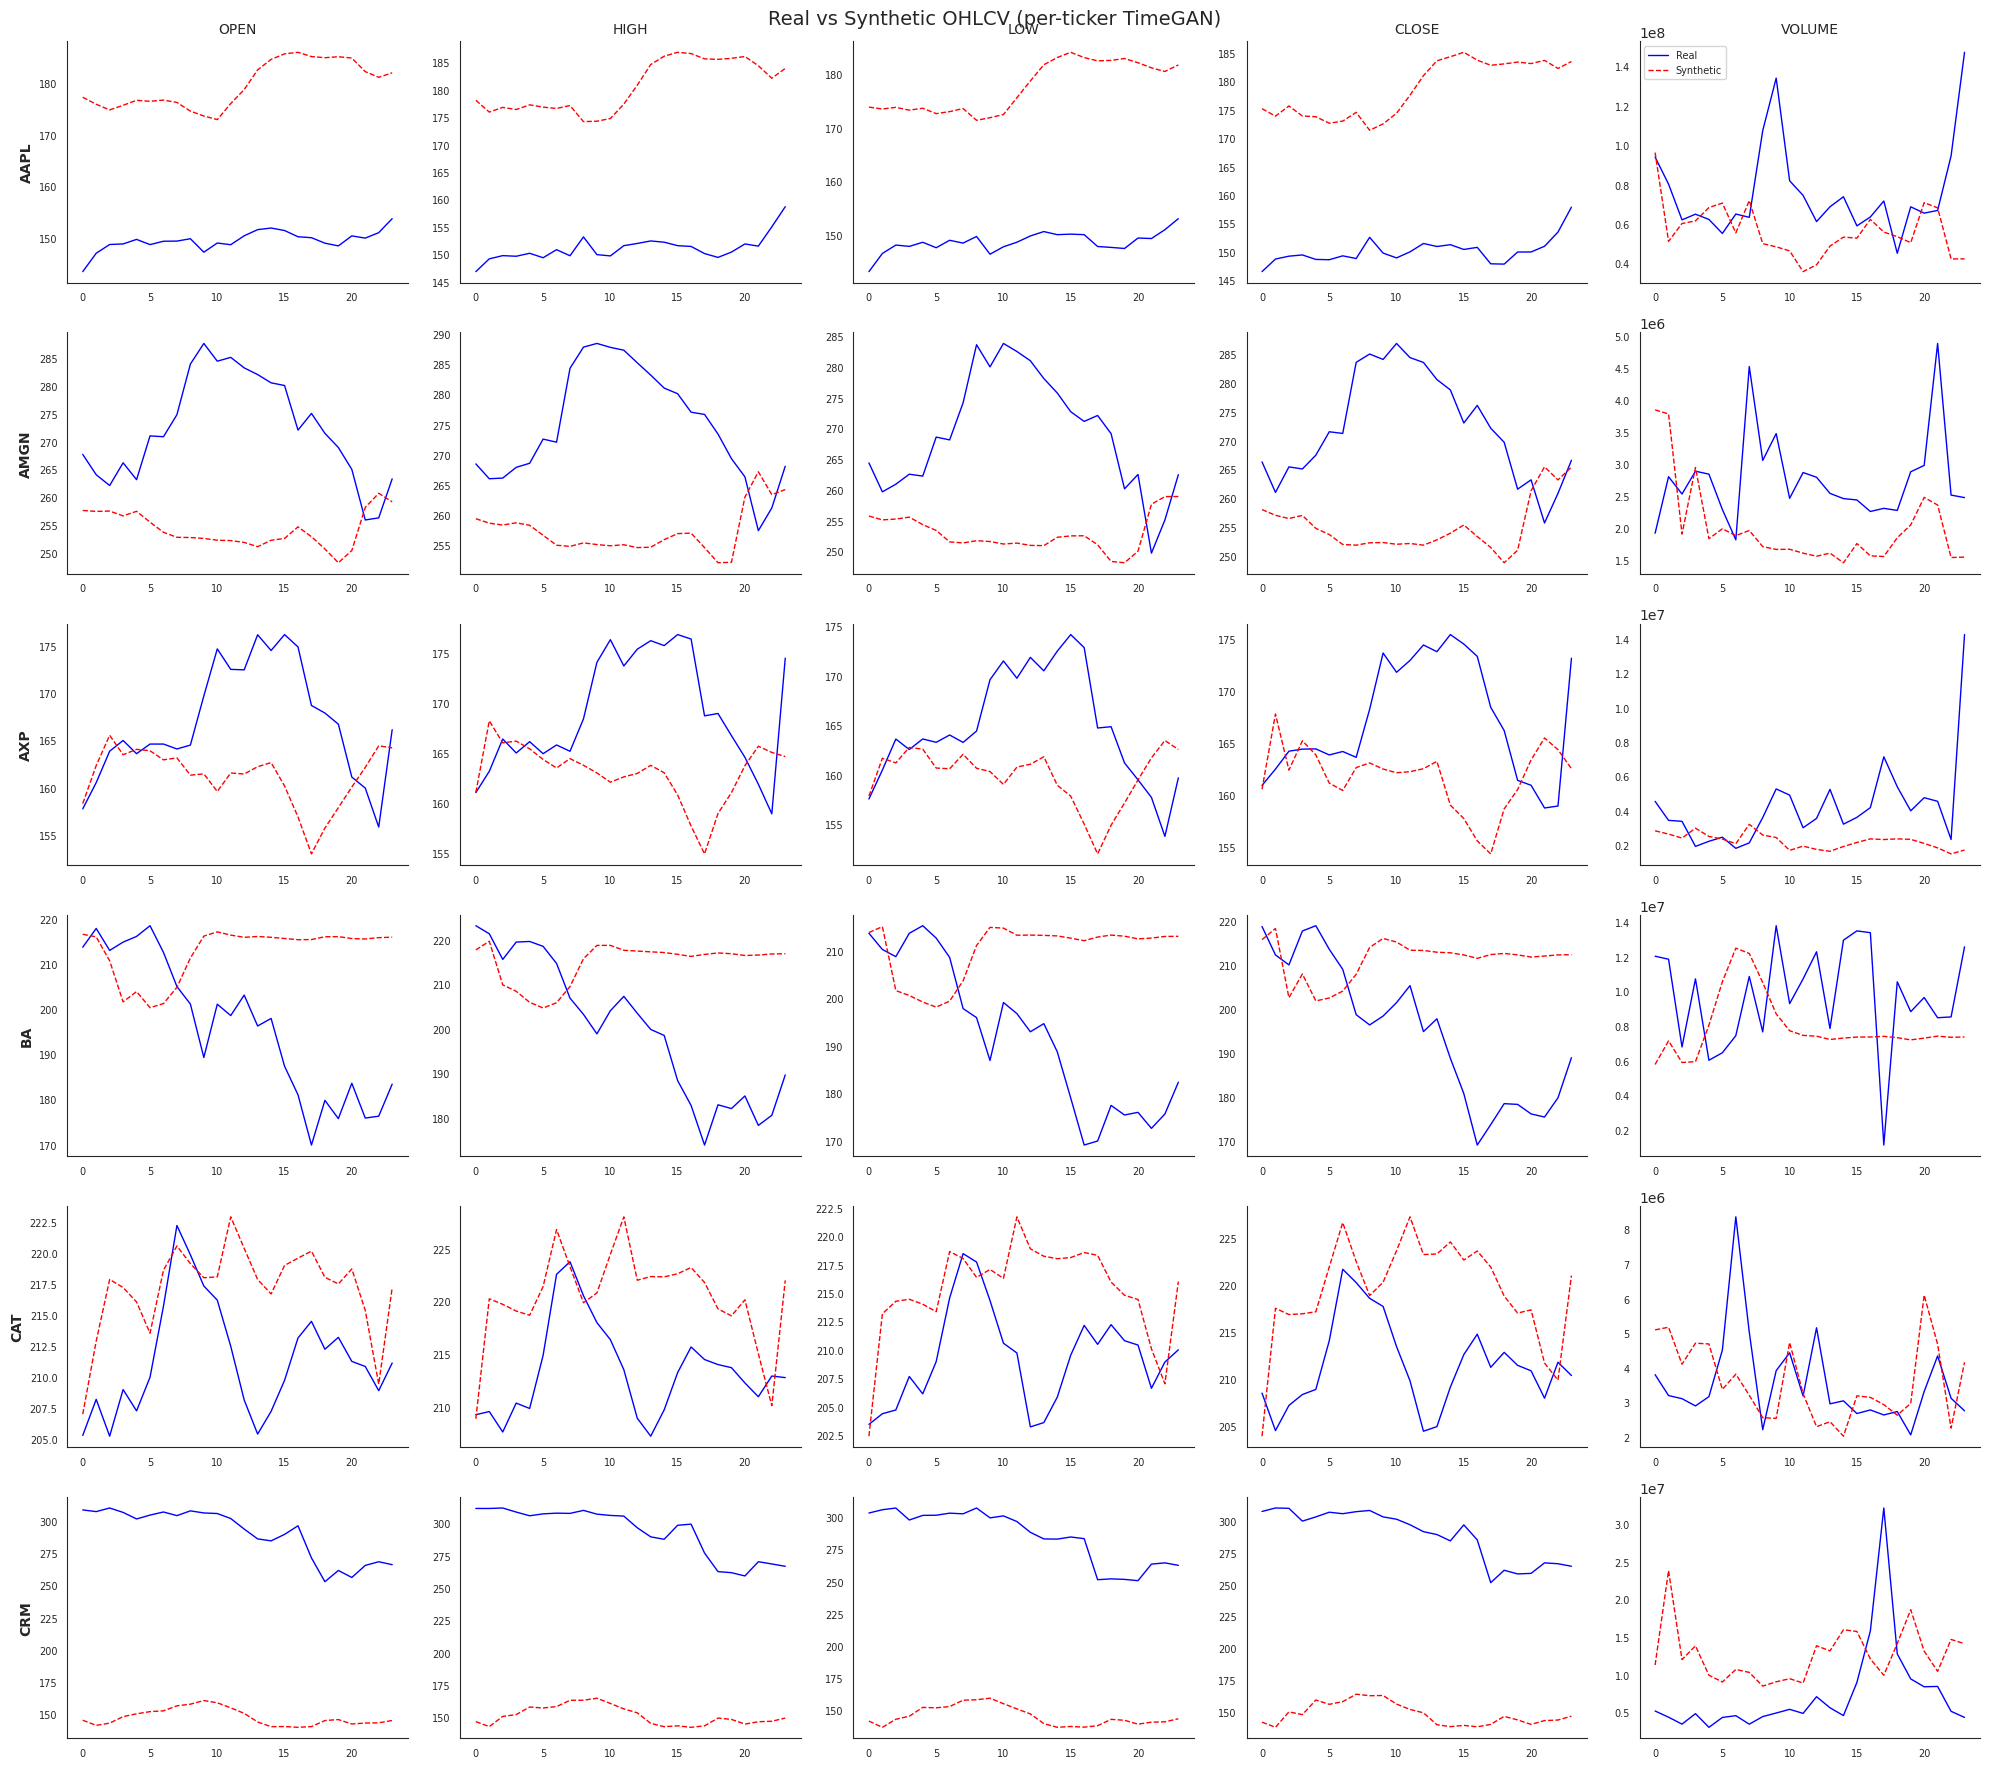

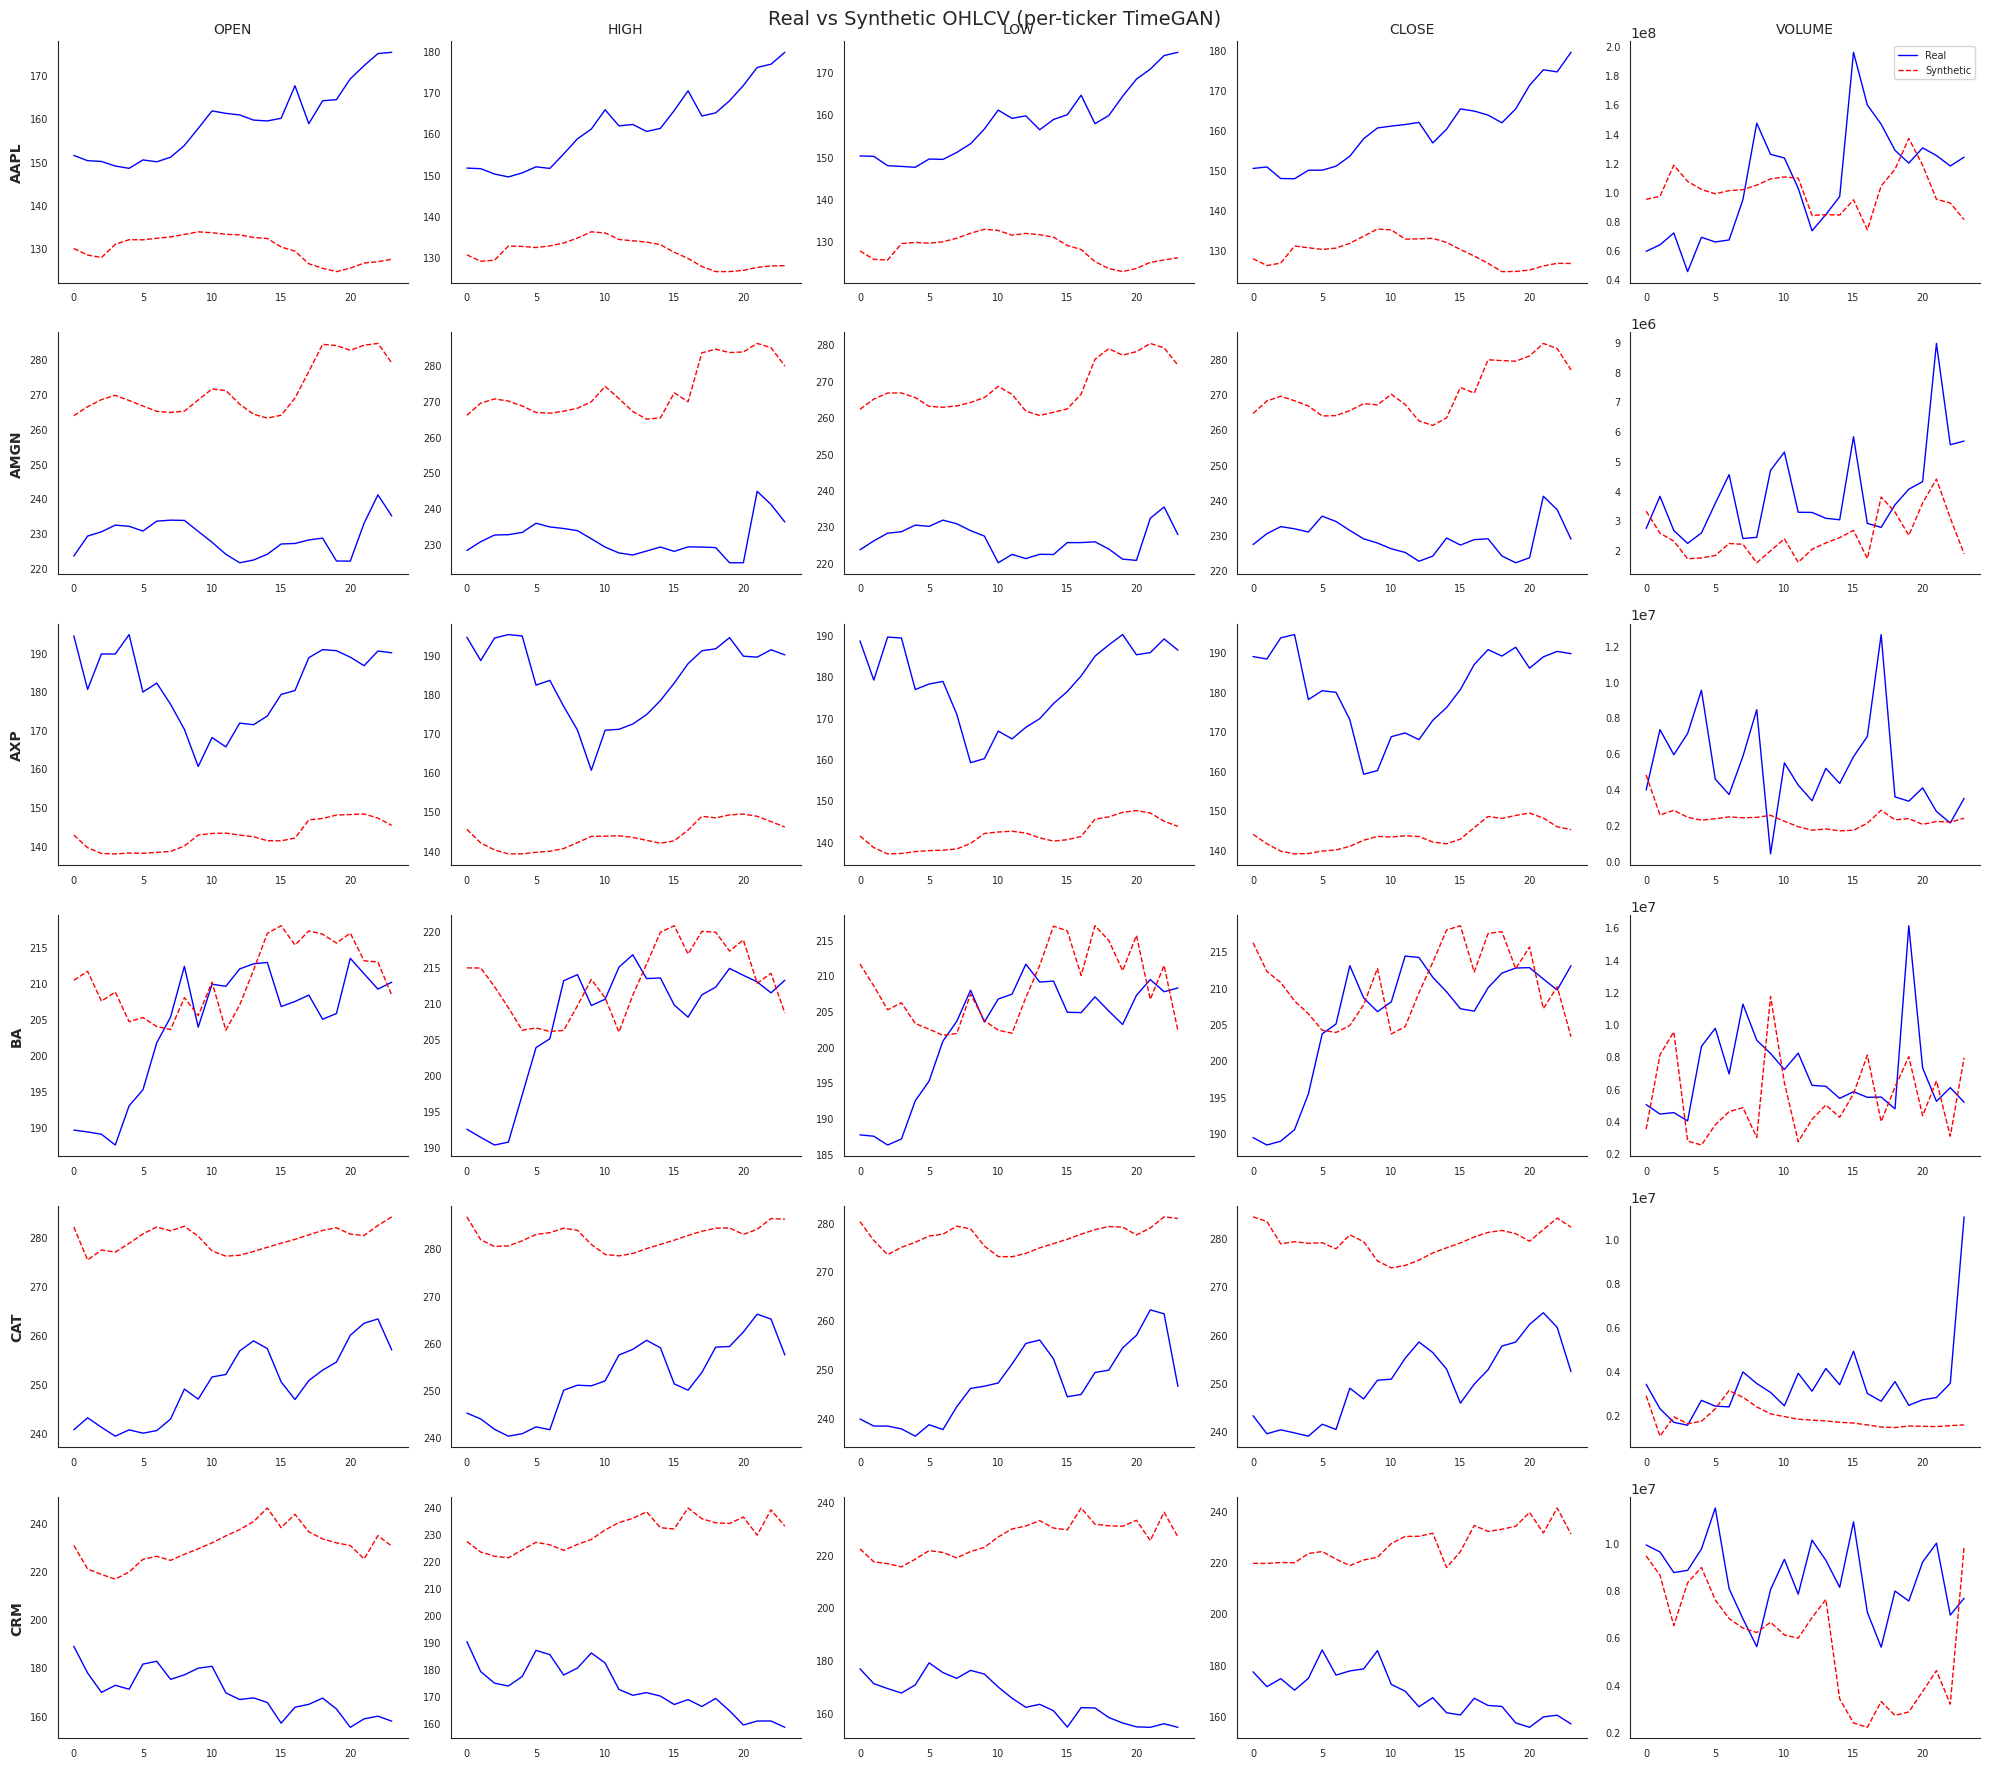

In [11]:
# Plot 6 sample tickers — Real vs Synthetic OHLCV
sample_tickers = TICKERS[:6]  # AAPL, AMGN, AXP, BA, CAT, CRM

fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 18))

with pd.HDFStore(hdf_store, mode='r') as store:
    for row, ticker in enumerate(sample_tickers):
        real_df = store[f'{ticker}/real']
        syn_df  = store[f'{ticker}/synthetic']
        
        # Pick a random real window and a random synthetic window
        real_idx = np.random.randint(0, len(real_df) - seq_len)
        real_window = real_df.iloc[real_idx:real_idx + seq_len]
        
        syn_idx = np.random.randint(0, len(syn_df) // seq_len) * seq_len
        syn_window = syn_df.iloc[syn_idx:syn_idx + seq_len]
        
        for col, feat in enumerate(feature_cols):
            ax = axes[row, col]
            ax.plot(real_window[feat].values, 'b-', lw=1, label='Real')
            ax.plot(syn_window[feat].values, 'r--', lw=1, label='Synthetic')
            if row == 0:
                ax.set_title(feat.upper(), fontsize=10)
            if col == 0:
                ax.set_ylabel(ticker, fontsize=10, fontweight='bold')
            if row == 0 and col == 4:
                ax.legend(fontsize=7)
            ax.tick_params(labelsize=7)

plt.suptitle('Real vs Synthetic OHLCV (per-ticker TimeGAN)', fontsize=14)
fig.tight_layout()
sns.despine()
plt.show()

## Correlation Check — Real vs Synthetic

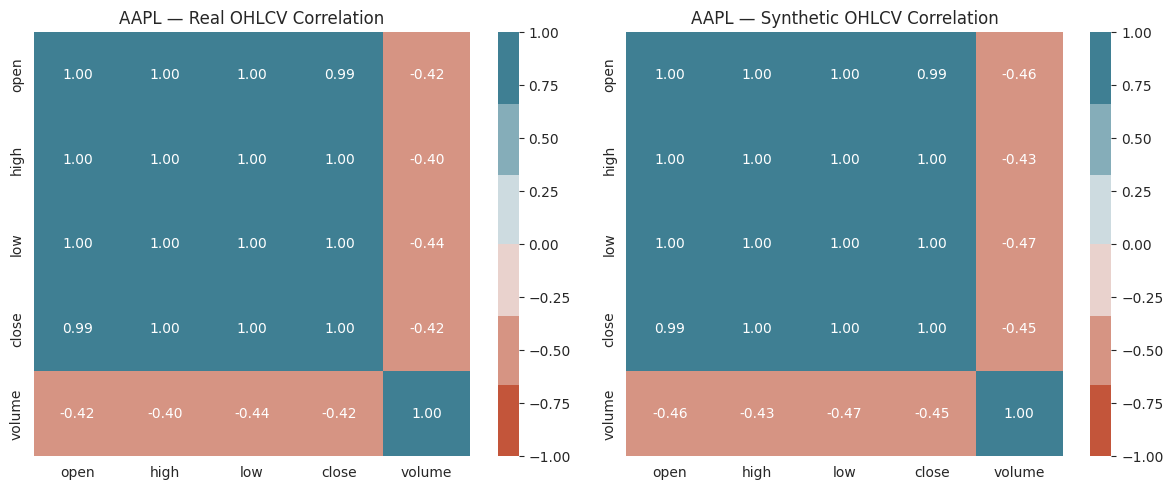

In [12]:
# Compare feature correlations for a single ticker
check_ticker = 'AAPL'

with pd.HDFStore(hdf_store, mode='r') as store:
    real_df = store[f'{check_ticker}/real']
    syn_df  = store[f'{check_ticker}/synthetic']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(real_df.corr(), annot=True, fmt='.2f', ax=ax1,
            cmap=sns.diverging_palette(20, 220), center=0, vmin=-1, vmax=1)
ax1.set_title(f'{check_ticker} — Real OHLCV Correlation')

sns.heatmap(syn_df.corr(), annot=True, fmt='.2f', ax=ax2,
            cmap=sns.diverging_palette(20, 220), center=0, vmin=-1, vmax=1)
ax2.set_title(f'{check_ticker} — Synthetic OHLCV Correlation')

fig.tight_layout()